## imports

In [1]:
import numpy as np
import math
from itertools import combinations, combinations_with_replacement as combinations_wr, product as iproduct
import random
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from time import perf_counter
from tqdm import trange
import warnings

## computation

In [2]:
def orient(ax, ay, bx, by, px, py):
    """
    Twice the signed area of triangle (A, B, P).
      > 0  →  P is strictly left  of directed line A→B
      < 0  →  P is strictly right of directed line A→B
      = 0  →  P lies on line AB
    Uses only integer arithmetic, so the result is exact.
    """
    return (bx - ax) * (py - ay) - (by - ay) * (px - ax)

In [3]:
def fair_alloc(rc, r3, b3, force=None):
    """
    rc: list of exactly 4 (red_count, blue_count) tuples.
    r3,b3: required counts per agent  (= totals / 3).
    force: only allow Agent 0 to have specific regions.

    Tries all C(4,2)=6 choices of which two regions go to one agent;
    the remaining two regions go to the other two agents (one each).

    Returns (True, alloc) where alloc[region] ∈ {0,1,2} is the agent,
    or (False, None).
    """
    if force and force not in ("adjacent", "opposite"):
        raise ValueError("Not a valid option to force.")
    
    for i, j in combinations(range(4), 2):
        if rc[i][0] + rc[j][0] == r3 and rc[i][1] + rc[j][1] == b3:
            rest = [k for k in range(4) if k not in (i, j)]   # exactly 2
            if rc[rest[0]] == (r3, b3):
                if force == "adjacent" and i + j == 3:
                    continue
                elif force == "opposite" and i + j != 3:
                    continue
                alloc = [None] * 4
                alloc[i] = alloc[j] = 0
                alloc[rest[0]] = 1
                alloc[rest[1]] = 2
                return True, alloc
    return False, None

In [4]:
def two_cuts_exist(pts, is_red, force=None, verbose=False):
    """
    Determine whether any pair of line cuts gives a fair 3-partition.

    Parameters
    ----------
    pts     : list of (x, y) with integer coordinates.
    is_red  : list of bool parallel to pts (True = red point).
    verbose : if True, output additional information.

    Returns
    -------
    (found: bool,  info: dict | None)
    info keys: 'line1', 'line2' (index pairs), 'regions' (4 (r,b) tuples),
               'alloc' (region→agent list).
    """
    if not all(isinstance(x, int) and isinstance(y, int) for (x,y) in pts):
        raise ValueError("Algorithm is only designed for integer input.")
    if len(pts) != len(set(pts)):
        raise ValueError("Input should not contain duplicate points.")
    
    m = len(pts)
    r_tot = sum(is_red);  b_tot = m - r_tot
    if r_tot % 3 or b_tot % 3:
        raise ValueError("The number of beads of each color must be divisible by 3.")
    r3, b3 = r_tot // 3, b_tot // 3

    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]

    all_lines = list(combinations(range(m), 2))   # O(m^2) candidate lines
    orient_cache = {
        (p1, p2): [orient(xs[p1], ys[p1], xs[p2], ys[p2], xs[q], ys[q]) for q in range(m)] 
        for p1, p2 in all_lines
    }

    # We use combinations with replacement because coincident cuts are needed 
    # for collinear input point sets.
    for (p1, p2), (p3, p4) in combinations_wr(all_lines, 2):
        
        # Skip pairs of coincident lines through distinct pairs of points 
        # (redundant work).
        if (
            (p1, p2) != (p3, p4) and 
            orient(xs[p1], ys[p1], xs[p2], ys[p2], xs[p3], ys[p3]) == 0 and 
            orient(xs[p1], ys[p1], xs[p2], ys[p2], xs[p4], ys[p4]) == 0
        ):
            continue

        # Orientation of every point w.r.t. line 1 (through p1,p2)
        # and line 2 (through p3,p4).
        s1 = orient_cache[(p1, p2)]
        s2 = orient_cache[(p3, p4)]

        # Boundary points (orientation == 0 on ≥1 line).
        on_both = [q for q in range(m) if s1[q] == 0 and s2[q] == 0]
        on_1    = [q for q in range(m) if s1[q] == 0 and s2[q] != 0]
        on_2    = [q for q in range(m) if s2[q] == 0 and s1[q] != 0]

        boundary = ([(q, 'both') for q in on_both] +
                    [(q, '1')    for q in on_1   ] +
                    [(q, '2')    for q in on_2   ])

        # Option sets: a point on "both" lines can go to any of the 4 regions;
        # a point on exactly one line can go to either side of that line.
        opts = [[(+1,+1),(+1,-1),(-1,+1),(-1,-1)] if side == 'both' else [+1,-1]
                for _, side in boundary]

        for combo in iproduct(*opts):
            f1 = s1[:]
            f2 = s2[:]
            for idx, (q, side) in enumerate(boundary):
                v = combo[idx]
                if side == 'both':
                    f1[q], f2[q] = v      # v is a (±1, ±1) tuple
                elif side == '1':
                    f1[q] = v
                else:
                    f2[q] = v

            # Count reds / blues in each of the 4 sign-pair regions.
            # Region index = 2*(f1>0) + (f2>0)  ∈ {0,1,2,3}.
            rc = [[0, 0] for _ in range(4)]
            for q in range(m):
                reg = (2 if f1[q] > 0 else 0) + (1 if f2[q] > 0 else 0)
                if is_red[q]:
                    rc[reg][0] += 1
                else:
                    rc[reg][1] += 1

            rc_t = [tuple(row) for row in rc]
            ok, alloc = fair_alloc(rc_t, r3, b3, force)

            if ok:
                info = {
                    'line1': (p1, p2), 
                    'line2': (p3, p4), 
                    'regions': rc_t, 
                    'alloc': alloc, 
                    'boundary': boundary, 
                    'combo': combo
                }
                if verbose:
                    print(f"  ✓  Line 1: pts[{p1}]={pts[p1]} – pts[{p2}]={pts[p2]}")
                    print(f"     Line 2: pts[{p3}]={pts[p3]} – pts[{p4}]={pts[p4]}")
                    print(f"     Regions (#red,#blue): {rc_t}")
                    print(f"     Allocation (region→agent): {alloc}")
                return True, info

    return False, None

In [5]:
def neck_to_lst(s):
    return [c == "R" for c in s]

In [6]:
assert two_cuts_exist(
    [(-3, 0), (-2, 0), (-1, 0), (1, 0), (2, 0), (3, 0)], 
    neck_to_lst("RRRBBB"), 
    force="opposite"
)[0]  # test that coincident cuts logic is working

In [7]:
def random_instance(r, b, dom_max=50, clustering=0, rng=None):
    """
    Generate r red + b blue points.
    Uses integer coordinates in [-dom_max, dom_max]^2.
    """
    if not (isinstance(r, int) and isinstance(b, int)):
        raise ValueError("Number of beads must be an integer.")
    if dom_max < 0:
        raise ValueError("Domain must be nonempty.")
    
    if rng is None:
        rng = random.Random()
    
    dom_max = math.floor(dom_max)
    m = r + b
    if m > (dom_max * 2 + 1)**2:
        raise ValueError("Domain too small.")
    elif m > 0.8 * (dom_max * 2 + 1)**2:
        warnings.warn("Domain very small relative to number of beads --- may increase execution time.")
    
    if clustering:
        clustering_bounds = (2, 10)
        if clustering < clustering_bounds[0] or clustering > clustering_bounds[1]:
            raise ValueError(
                f"Clustering value too extreme --- it should be between {clustering_bounds[0]} and {clustering_bounds[1]}."
            )
        sigma = dom_max / clustering

        coords = []
        red_weights = []
        blue_weights = []

        for x in range(-dom_max, dom_max + 1):
            for y in range(-dom_max, dom_max + 1):
                coords.append((x, y))
                d_edge = min(dom_max - abs(x), dom_max - abs(y))
                
                red_w = math.exp(-(x*x + y*y) / (2 * sigma**2))
                blue_w = math.exp(-(d_edge*d_edge) / (2 * sigma**2))
                
                red_weights.append(red_w)
                blue_weights.append(blue_w)
                
        available = list(range(len(coords)))
        pos_of = {v: i for i, v in enumerate(available)}  # value → position in available
        available_w_r = [red_weights[i] for i in available]
        available_w_b = [blue_weights[i] for i in available]

        def _available_remove(idx):
            p = pos_of.pop(idx)
            last = available[-1]
            available[p] = last
            available.pop()
            available_w_r[p] = available_w_r[-1]
            available_w_r.pop()
            available_w_b[p] = available_w_b[-1]
            available_w_b.pop()
            if last != idx:
                pos_of[last] = p

        pts = []
        for _ in range(r):
            idx = rng.choices(
                available,
                weights=available_w_r,
                k=1,
            )[0]
            pts.append(coords[idx])
            _available_remove(idx)
        for _ in range(b):
            idx = rng.choices(
                available,
                weights=available_w_b,
                k=1,
            )[0]
            pts.append(coords[idx])
            _available_remove(idx)
        
    else:
        pts_set = set()
        while len(pts_set) < m:
            pts_set.add((rng.randint(-dom_max, dom_max), rng.randint(-dom_max, dom_max)))
        pts = list(pts_set)
    
    is_red = [True] * r + [False] * b
    if not clustering:  # red points are forced to be in the interior in the tightly clustered layout
        rng.shuffle(is_red)
    
    return pts, is_red, dom_max

In [8]:
def stress_test(r, b, trials, seed=0, force=None, verbose_fails=True, **kwargs):
    """
    Run *trials* random instances; report any where 2 cuts are insufficient.

    Parameters
    ----------
    r, b          : red and blue counts (must be multiples of 3).
    trials        : number of random instances to try.
    seed          : RNG seed for reproducibility.
    verbose_fails : if True, print the point set for each failure.

    Returns
    -------
    Number of failures found.
    """
    rng    = random.Random(seed)
    n_fail = 0
    t0     = perf_counter()

    for trial in trange(trials):
        pts, is_red, dom_max = random_instance(r, b, rng=rng, **kwargs)
        found, _ = two_cuts_exist(pts, is_red, force=force)
        if not found:
            n_fail += 1
            if verbose_fails:
                colors = ''.join('R' if c else 'B' for c in is_red)
                print(f"  [Trial {trial}] NO 2-cut solution exists for this instance:")
                print(f"    pts    = {pts}")
                print(f"    colors = {colors}")

    elapsed = perf_counter() - t0
    verdict = "ALL PASS ✓" if n_fail == 0 else f"{n_fail} FAILURE(S) ✗"
    print(f"m={r + b}, r={r}, b={b} | {trials} trials | {verdict} | {elapsed:.2f}s")
    return n_fail

## visualization

In [9]:
def visualize_solution(pts, is_red, dom_max, info):
    """
    Visualize a fair partition returned by two_cuts_exist().

    Assumes info contains:
        line1, line2, regions, alloc, boundary, combo

    and that point_regions() is defined.
    """
    if info is not None:
        (p1, p2) = info['line1']
        (p3, p4) = info['line2']
        alloc = info['alloc']
        rc = info['regions']

    fig, ax = plt.subplots(figsize=(8, 8))

    # ------------------------------------------------------------
    # Plot window
    # ------------------------------------------------------------

    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]

    pad = math.ceil(0.2 * dom_max)

    xmin = -dom_max - pad
    xmax = dom_max + pad
    ymin = -dom_max - pad
    ymax = dom_max + pad

    if info is not None:
        # ------------------------------------------------------------
        # Line coefficients
        # ------------------------------------------------------------

        def line_coeffs(a, b):
            x1, y1 = pts[a]
            x2, y2 = pts[b]

            A = -(y2 - y1)
            B = x2 - x1
            C = -(A * x1 + B * y1)

            return A, B, C

        A1, B1, C1 = line_coeffs(p1, p2)
        A2, B2, C2 = line_coeffs(p3, p4)

        # ------------------------------------------------------------
        # Background ownership shading
        # ------------------------------------------------------------

        xx = np.linspace(xmin, xmax, 600)
        yy = np.linspace(ymin, ymax, 600)

        X, Y = np.meshgrid(xx, yy)

        S1 = A1 * X + B1 * Y + C1
        S2 = A2 * X + B2 * Y + C2

        region = (S1 > 0).astype(int) * 2 + (S2 > 0).astype(int)

        display = np.vectorize(lambda r: alloc[r])(region)

        agent_cmap = ListedColormap([
            "#ffe5b4",  # agent 0
            "#d8f3dc",  # agent 1
            "#dbeafe"   # agent 2
        ])

        ax.contourf(
            X,
            Y,
            display,
            levels=[-0.5, 0.5, 1.5, 2.5],
            cmap=agent_cmap,
            alpha=0.40
        )

        # ------------------------------------------------------------
        # Draw the two lines
        # ------------------------------------------------------------

        def draw_line(a, b, linestyle='--', lw=2):
            x1, y1 = pts[a]
            x2, y2 = pts[b]

            if x1 == x2:
                ax.axvline(x1, linestyle=linestyle, color="k", linewidth=lw)
            else:
                m = (y2 - y1) / (x2 - x1)
                c = y1 - m * x1

                xvals = np.array([xmin, xmax])
                yvals = m * xvals + c

                ax.plot(xvals, yvals, linestyle=linestyle, color="k", linewidth=lw)

        draw_line(p1, p2)
        draw_line(p3, p4)

        # ------------------------------------------------------------
        # Highlight defining points
        # ------------------------------------------------------------

        ax.scatter(
            [pts[p1][0], pts[p2][0]],
            [pts[p1][1], pts[p2][1]],
            s=180,
            facecolors='none',
            edgecolors='green',
            linewidths=2,
            zorder=8
        )

        ax.scatter(
            [pts[p3][0], pts[p4][0]],
            [pts[p3][1], pts[p4][1]],
            s=180,
            facecolors='none',
            edgecolors='green',
            linewidths=2,
            zorder=8
        )

    # ------------------------------------------------------------
    # Plot beads
    # ------------------------------------------------------------

    for i, (x, y) in enumerate(pts):

        ax.scatter(
            x,
            y,
            c='red' if is_red[i] else 'blue',
            s=80,
            zorder=10
        )

        ax.annotate(
            str(i),
            (x, y),
            xytext=(4, 4),
            textcoords='offset points',
            zorder=11
        )

    if info is not None:
        # ------------------------------------------------------------
        # Region labels
        # ------------------------------------------------------------

        for reg in range(4):

            mask = region == reg

            if not np.any(mask):
                continue

            cx = X[mask].mean()
            cy = Y[mask].mean()

            label = (
                f"A{alloc[reg]}\n"
                f"R={rc[reg][0]}  B={rc[reg][1]}"
            )

            ax.text(
                cx,
                cy,
                label,
                ha='center',
                va='center',
                fontsize=10,
                bbox=dict(boxstyle='round', alpha=0.8)
            )

    # ------------------------------------------------------------
    # Cosmetics
    # ------------------------------------------------------------

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_aspect('equal')
    ax.grid(True)

    if info is not None:
        ax.set_title(
            f"Line1 = {info['line1']}    "
            f"Line2 = {info['line2']}"
        )

    plt.show()

In [10]:
def single_run(*args, visualize=True, **kwargs):
    pts, is_red, dom_max = random_instance(*args, **kwargs)
    found, info = two_cuts_exist(pts, is_red, verbose=True);
    if visualize:
        visualize_solution(pts, is_red, dom_max, info)

  ✓  Line 1: pts[0]=(5, -4) – pts[1]=(-13, -8)
     Line 2: pts[0]=(5, -4) – pts[4]=(45, -38)
     Regions (#red,#blue): [(1, 1), (1, 4), (1, 4), (0, 3)]
     Allocation (region→agent): [0, 1, 2, 0]


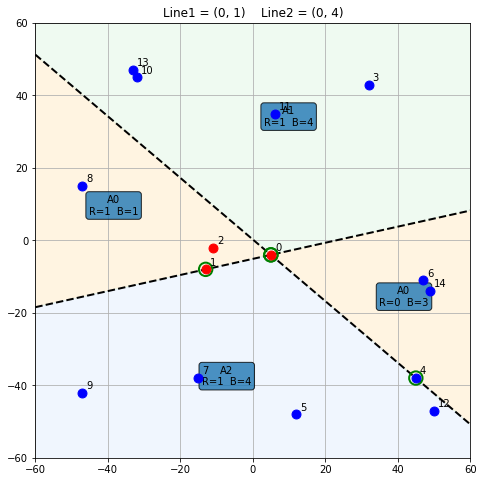

In [11]:
single_run(3, 12, clustering=7)

## experiments

In [12]:
def generate_configs(lo, hi):
    lo = math.ceil(lo / 3) * 3
    configs = []
    for total in range(lo, hi + 1, 3):
        for r in range(3, total // 2 + 1, 3):
            b = total - r
            if b % 3 == 0 and r <= b:
                configs.append((r, b))
    
    return configs

In [13]:
m_bounds = (6,6)
seed = random.randint(0, 10**6)

total_fails = 0
for r, b in generate_configs(*m_bounds):
    total_fails += stress_test(r, b, trials=2000, seed=seed, force="opposite", dom_max=500, clustering=0)

print(f"\nTotal failures across all configurations: {total_fails}")
if total_fails:
    print(f"→ Counterexample{'s' if total_fails > 1 else ''} found! 2 cuts are NOT always sufficient.")
else:
    print("→ No counterexample to 2-cut sufficiency found in these trials.")

100%|██████████████████████████████████████████████████████████| 2000/2000 [00:04<00:00, 499.53it/s]

m=6, r=3, b=3 | 2000 trials | ALL PASS ✓ | 4.16s

Total failures across all configurations: 0
→ No counterexample to 2-cut sufficiency found in these trials.


## counterexamples

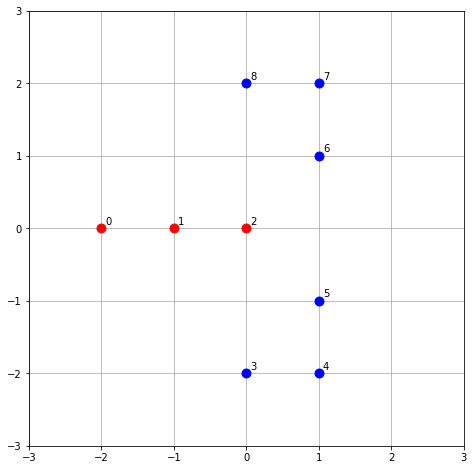

In [14]:
pts    = [(-2, 0), (-1, 0), (0, 0), (0, -2), (1, -2), (1, -1), (1, 1), (1, 2), (0, 2)]
is_red = neck_to_lst("RRRBBBBBB")
dom_max = 2
_, info = two_cuts_exist(pts, is_red, force="opposite", verbose=True)
visualize_solution(pts, is_red, dom_max, info)